Усреднённые показатели за 2021-2024 гг.:
Pyaterochka: выручка=2354.1 млрд руб., маржа=0.244, средний чек=452 руб.
Perekrestok: выручка=408.2 млрд руб., маржа=0.244, средний чек=694 руб.
Magnit: выручка=2449.1 млрд руб., маржа=0.229, средний чек=399 руб.
Lenta: выручка=631.3 млрд руб., маржа=0.220, средний чек=962 руб.

Оценка предельных издержек (руб.):
Pyaterochka: 342
Perekrestok: 525
Magnit: 308
Lenta: 750
Episode 0, epsilon=0.998
Episode 50, epsilon=0.903
Episode 100, epsilon=0.817
Episode 150, epsilon=0.739
Episode 200, epsilon=0.669
Episode 250, epsilon=0.605
Episode 300, epsilon=0.547
Episode 350, epsilon=0.495
Episode 400, epsilon=0.448
Episode 450, epsilon=0.405
Episode 500, epsilon=0.367
Episode 550, epsilon=0.332
Episode 600, epsilon=0.300
Episode 650, epsilon=0.272
Episode 700, epsilon=0.246
Episode 750, epsilon=0.222
Episode 800, epsilon=0.201
Episode 850, epsilon=0.182
Episode 900, epsilon=0.165
Episode 950, epsilon=0.149
Episode 1000, epsilon=0.135
Episode 1050, epsilon=

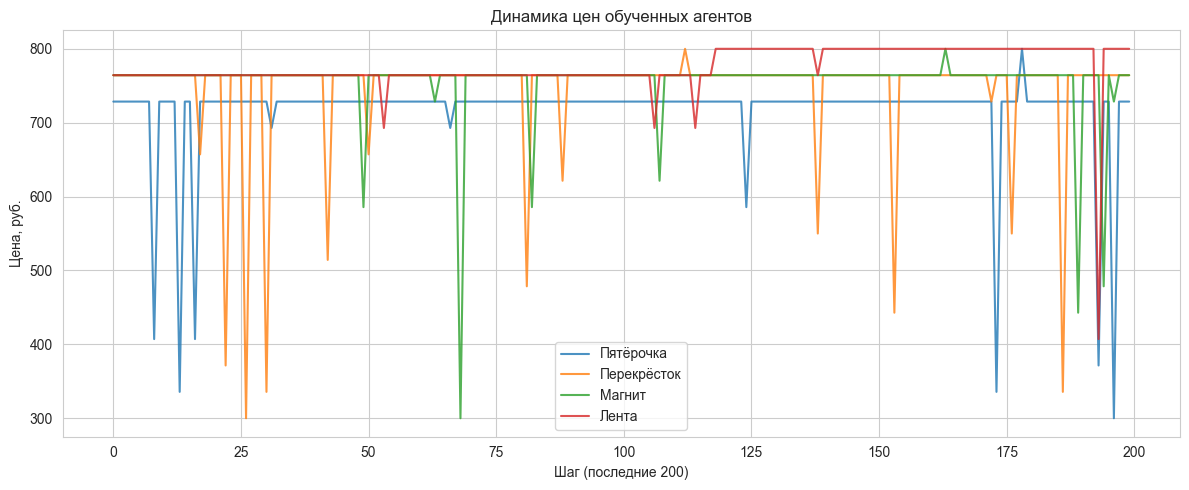

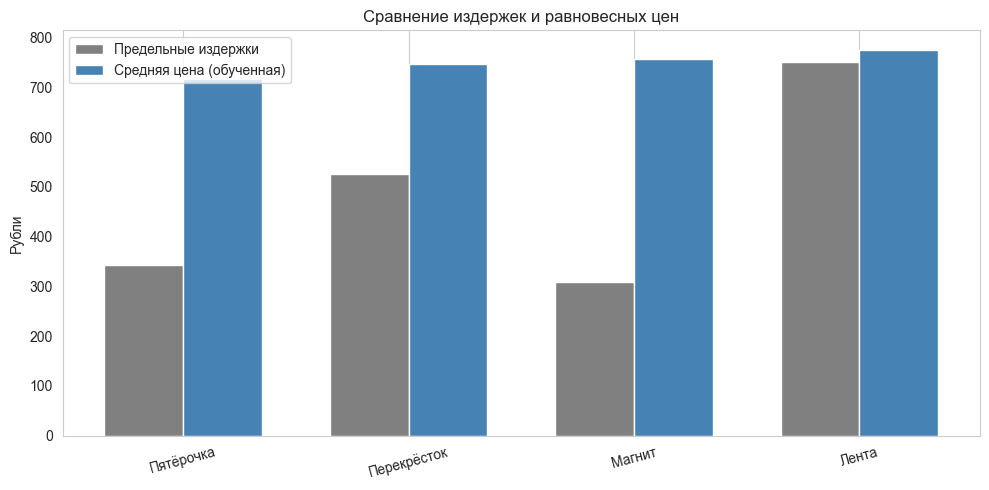

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random
import torch.nn.functional as F

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

data = {
    'Pyaterochka': {
        'revenue': {2021: 1779.6, 2022: 2122.8, 2023: 2491.0, 2024: 3023.0},
        'margin': {2021: 0.254, 2022: 0.241, 2023: 0.241, 2024: 0.240},
        'avg_check': {2021: 409, 2022: 441, 2023: 461, 2024: 499},
        'lfl': {2021: 0.056, 2022: 0.117, 2023: 0.098, 2024: 0.144}
    },
    'Perekrestok': {
        'revenue': {2021: 337.4, 2022: 385.5, 2023: 418.9, 2024: 491.0},
        'margin': {2021: 0.254, 2022: 0.241, 2023: 0.241, 2024: 0.240},
        'avg_check': {2021: 626, 2022: 671, 2023: 713, 2024: 768},
        'lfl': {2021: 0.038, 2022: 0.071, 2023: 0.083, 2024: 0.144}
    },
    'Magnit': {
        'revenue': {2021: 1856.1, 2022: 2352.0, 2023: 2544.7, 2024: 3043.4},
        'margin': {2021: 0.234, 2022: 0.228, 2023: 0.227, 2024: 0.225},
        'avg_check': {2021: 351, 2022: 388, 2023: 405, 2024: 452},
        'lfl': {2021: 0.070, 2022: 0.121, 2023: 0.055, 2024: 0.112}
    },
    'Lenta': {
        'revenue': {2021: 483.6, 2022: 537.4, 2023: 615.9, 2024: 888.3},
        'margin': {2021: 0.230, 2022: 0.225, 2023: 0.210, 2024: 0.216},
        'avg_check': {2021: 1093, 2022: 1051, 2023: 937, 2024: 767},
        'lfl': {2021: 0.024, 2022: 0.023, 2023: 0.046, 2024: 0.127}
    }
}

def average_over_years(company_data, metric):
    """Возвращает среднее значение метрики по всем доступным годам (игнорируя None)"""
    values = [v for v in company_data[metric].values() if v is not None]
    return sum(values) / len(values) if values else None

companies = ['Pyaterochka', 'Perekrestok', 'Magnit', 'Lenta']
avg_metrics = {}

for company in companies:
    avg_metrics[company] = {
        'revenue': average_over_years(data[company], 'revenue'),
        'margin': average_over_years(data[company], 'margin'),
        'avg_check': average_over_years(data[company], 'avg_check'),
        'lfl': average_over_years(data[company], 'lfl')
    }

# Печать усреднённых значений (для проверки)
print("Усреднённые показатели за 2021-2024 гг.:")
for company in companies:
    print(f"{company}: выручка={avg_metrics[company]['revenue']:.1f} млрд руб., "
          f"маржа={avg_metrics[company]['margin']:.3f}, "
          f"средний чек={avg_metrics[company]['avg_check']:.0f} руб.")

# Расчёт предельных издержек (MC = средний чек * (1 - маржа))
marginal_costs = []
for company in companies:
    ac = avg_metrics[company]['avg_check']
    m = avg_metrics[company]['margin']
    mc = ac * (1 - m) if ac and m else 200.0
    marginal_costs.append(mc)

print("\nОценка предельных издержек (руб.):")
for i, company in enumerate(companies):
    print(f"{company}: {marginal_costs[i]:.0f}")

# класс среды
class OligopolyMarketEnv:
    """ Многоагентная среда с динамическим спросом (через ОДУ) """
    def __init__(self, n_firms=4, marginal_costs=None,
                 quality_params=None, mu=0.2, a0=0.0,
                 price_min=300, price_max=800, n_price_levels=15,
                 demand_noise=0.03, market_size=1000,
                 partial_obs=False, alpha_demand=0.3, dt=1.0):
        self.n_firms = n_firms
        self.mu = mu
        self.a0 = a0
        self.demand_noise = demand_noise
        self.partial_obs = partial_obs
        self.market_size = market_size
        self.alpha_demand = alpha_demand
        self.dt = dt

        # издержки
        if marginal_costs is None:
            self.marginal_costs = [200.0] * n_firms
        else:
            self.marginal_costs = marginal_costs

        # качества (по умолчанию все 1.0)
        if quality_params is None:
            self.quality_params = [1.0] * n_firms
        else:
            self.quality_params = quality_params

        # цены (дискретные уровни)
        self.price_levels = np.linspace(price_min, price_max, n_price_levels)
        self.action_space = n_price_levels
        self.action_space_n = [n_price_levels] * n_firms

        # наблюдения
        if partial_obs:
            self.observation_dim = 2  # каждый агент видит свою цену и свои продажи
        else:
            self.observation_dim = n_firms + 1  # цены всех фирм + средние продажи

        self.reset()

    def reset(self):
        self.current_prices = np.random.choice(self.price_levels, self.n_firms)
        self.current_demand = np.ones(self.n_firms) * (self.market_size / self.n_firms)
        self.last_sales = np.zeros(self.n_firms)
        self.current_step = 0
        return self._get_observations()

    def step(self, actions):
        prices = np.array([self.price_levels[a] for a in actions])
        self.current_prices = prices
        target_demand = self._compute_demand(prices)
        self.current_demand = self._update_demand(self.current_demand, target_demand)
        sales = self.current_demand.copy()
        if self.demand_noise > 0:
            noise = np.random.normal(1.0, self.demand_noise, self.n_firms)
            sales = sales * noise
        sales = np.maximum(sales, 0)
        self.last_sales = sales
        profits = (prices - self.marginal_costs) * sales
        next_obs = self._get_observations()
        self.current_step += 1
        done = False
        info = {'prices': prices, 'sales': sales, 'profits': profits}
        return next_obs, profits.tolist(), done, info

    def _compute_demand(self, prices):
        numerators = np.exp((self.quality_params - prices) / self.mu)
        denominator = np.sum(numerators) + np.exp(self.a0 / self.mu)
        shares = numerators / denominator
        return shares * self.market_size

    def _update_demand(self, q, D):
        return q + self.alpha_demand * (D - q) * self.dt

    def _get_observations(self):
        obs = []
        if self.partial_obs:
            for i in range(self.n_firms):
                obs_i = np.array([
                    self.current_prices[i] / 100.0,
                    self.last_sales[i] / self.market_size
                ])
                obs.append(obs_i)
        else:
            norm_prices = self.current_prices / 100.0
            norm_avg_sales = np.mean(self.last_sales) / self.market_size
            global_obs = np.concatenate([norm_prices, [norm_avg_sales]])
            obs = [global_obs.copy() for _ in range(self.n_firms)]
        return obs

class DQNNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_sizes=[128, 128]):
        super(DQNNetwork, self).__init__()
        layers = []
        prev_size = state_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.ReLU())
            prev_size = h
        layers.append(nn.Linear(prev_size, action_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states), np.array(actions), np.array(rewards),
                np.array(next_states), np.array(dones))

    def __len__(self):
        return len(self.buffer)

class DQNAgent:
    def __init__(self, agent_id, state_dim, action_dim, hidden_sizes=[128, 128],
                 learning_rate=1e-4, gamma=0.99, epsilon_start=1.0,
                 epsilon_end=0.05, epsilon_decay=0.998, buffer_size=100000,
                 batch_size=128, target_update_freq=200, device='cpu'):
        self.agent_id = agent_id
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        self.device = device
        self.step_count = 0

        self.q_network = DQNNetwork(state_dim, action_dim, hidden_sizes).to(device)
        self.target_network = DQNNetwork(state_dim, action_dim, hidden_sizes).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=learning_rate)
        self.replay_buffer = ReplayBuffer(buffer_size)

    def act(self, state, eval_mode=False):
        if not eval_mode and np.random.random() < self.epsilon:
            return np.random.randint(self.action_dim)
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_values = self.q_network(state_tensor)
        return torch.argmax(q_values, dim=1).item()

    def update(self):
        if len(self.replay_buffer) < self.batch_size:
            return 0.0
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.batch_size)
        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(self.device)

        current_q = self.q_network(states).gather(1, actions)
        with torch.no_grad():
            next_actions = self.q_network(next_states).argmax(dim=1, keepdim=True)
            next_q = self.target_network(next_states).gather(1, next_actions)
            target_q = rewards + (1 - dones) * self.gamma * next_q

        loss = nn.MSELoss()(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_network.parameters(), 1.0)
        self.optimizer.step()

        self.step_count += 1
        if self.step_count % self.target_update_freq == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())

        return loss.item()

    def remember(self, state, action, reward, next_state, done):
        self.replay_buffer.add(state, action, reward, next_state, done)

env = OligopolyMarketEnv(
    n_firms=4,
    marginal_costs=marginal_costs,
    quality_params=[1.0, 1.0, 1.0, 1.0],
    mu=0.2,
    alpha_demand=0.3,
    demand_noise=0.03,
    partial_obs=False
)

agents = [DQNAgent(agent_id=i, state_dim=env.observation_dim, action_dim=env.action_space)
          for i in range(env.n_firms)]

num_episodes = 1500 # количество эпизодов
steps_per_episode = 200
price_history = []
profit_history = []

for episode in range(num_episodes):
    states = env.reset()
    for step in range(steps_per_episode):
        actions = [agents[i].act(states[i]) for i in range(env.n_firms)]
        next_states, rewards, done, info = env.step(actions)
        for i in range(env.n_firms):
            agents[i].remember(states[i], actions[i], rewards[i], next_states[i], done)
            agents[i].update()
        states = next_states
        price_history.append(info['prices'])
        profit_history.append(info['profits'])
    # затухание epsilon
    for agent in agents:
        agent.epsilon = max(agent.epsilon_end, agent.epsilon * agent.epsilon_decay)

    if episode % 50 == 0:
        print(f"Episode {episode}, epsilon={agents[0].epsilon:.3f}")

# результаты
price_history = np.array(price_history)
profit_history = np.array(profit_history)
last_steps = min(200, len(price_history))
prices_last = price_history[-last_steps:]
profits_last = profit_history[-last_steps:]

avg_prices = np.mean(prices_last, axis=0)
avg_profits = np.mean(profits_last, axis=0)
costs = env.marginal_costs
firm_names = ['Пятёрочка', 'Перекрёсток', 'Магнит', 'Лента']

print("Результаты (4 фирмы, усреднённые данные за 2021-2024)")
print(f"Усреднение по последним {last_steps} шагам\n")

for i, name in enumerate(firm_names):
    markup_pct = (avg_prices[i] - costs[i]) / costs[i] * 100
    print(f"{name}:")
    print(f"  Средняя цена: {avg_prices[i]:.2f} руб.")
    print(f"  Предельные издержки: {costs[i]:.2f} руб.")
    print(f"  Наценка: {markup_pct:.1f}%")
    print(f"  Средняя прибыль за шаг: {avg_profits[i]:.2f}\n")

print("Волатильность цен (последние 200 шагов):")
for i, name in enumerate(firm_names):
    print(f"  {name}: {np.std(prices_last[:, i]):.2f} руб.")

bertrand_deviation = np.mean(avg_prices - costs)
print(f"\nСреднее отклонение от равновесия Бертрана: {bertrand_deviation:.2f} руб.")

plt.figure(figsize=(12, 5))
for i, name in enumerate(firm_names):
    plt.plot(prices_last[:, i], label=name, alpha=0.8)
plt.xlabel('Шаг (последние 200)')
plt.ylabel('Цена, руб.')
plt.title('Динамика цен обученных агентов')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# График средних цен vs издержки
plt.figure(figsize=(10, 5))
x = np.arange(len(firm_names))
width = 0.35
plt.bar(x - width/2, costs, width, label='Предельные издержки', color='gray')
plt.bar(x + width/2, avg_prices, width, label='Средняя цена (обученная)', color='steelblue')
plt.xticks(x, firm_names, rotation=15)
plt.ylabel('Рубли')
plt.title('Сравнение издержек и равновесных цен')
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

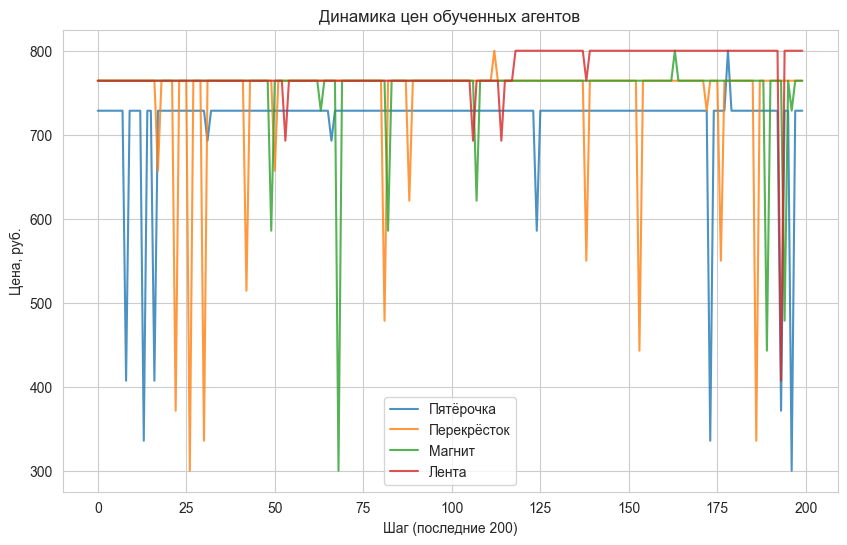

In [3]:
plt.figure(figsize=(10,6))
for i, firm in enumerate(['Пятёрочка','Перекрёсток','Магнит','Лента']):
    plt.plot(price_history[-200:, i], label=firm, alpha=0.8)
plt.xlabel('Шаг (последние 200)')
plt.ylabel('Цена, руб.')
plt.title('Динамика цен обученных агентов')
plt.legend()
plt.grid(True)
plt.savefig('price_dynamics.png')